# Future Property Price Prediction

In [44]:
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import mlflow
from mlflow.data import from_pandas
import dagshub
import mlflow.pyfunc

In [45]:
data = pd.read_csv('Datasets/Future_Price.csv')

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_per_SqFt_in_Lakhs         250000 non-null  float64
 8   Price_in_Lakhs                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Direction_Facing                250000 non-null  object 
 12  Floor_No        

### Domain Data Validation

In [47]:
data.describe(include='all')

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_per_SqFt_in_Lakhs,Price_in_Lakhs,Year_Built,...,Public_Transport_Accessibility,Parking_Space,Security,Clubhouse,Garden,Gym,Playground,Pool,Amenity_Score,Future_Price_5Y
count,250000.000000,250000,250000,250000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000,250000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
unique,NaN,20,42,500,3,NaN,NaN,NaN,NaN,NaN,...,3,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Odisha,Coimbatore,Locality_296,Villa,NaN,NaN,NaN,NaN,NaN,...,High,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,12681,6461,567,83744,NaN,NaN,NaN,NaN,NaN,...,83705,125456,125233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,125000.500000,NaN,NaN,NaN,NaN,2.999396,2749.813216,0.130583,254.586854,2006.520012,...,NaN,NaN,NaN,0.600236,0.600708,0.599840,0.599120,0.600384,0.598557,486.103864
std,72168.927986,NaN,NaN,NaN,NaN,1.415521,1300.606954,0.130719,141.349921,9.808575,...,NaN,NaN,NaN,0.489851,0.489754,0.489932,0.490078,0.489820,0.141844,272.828372
min,1.000000,NaN,NaN,NaN,NaN,1.000000,500.000000,0.002000,10.000000,1990.000000,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.171000,15.678283
25%,62500.750000,NaN,NaN,NaN,NaN,2.000000,1623.000000,0.048000,132.550000,1998.000000,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.490000,253.992385
50%,125000.500000,NaN,NaN,NaN,NaN,3.000000,2747.000000,0.092000,253.870000,2007.000000,...,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.596000,482.312561
75%,187500.250000,NaN,NaN,NaN,NaN,4.000000,3874.000000,0.160000,376.880000,2015.000000,...,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.704000,709.519297


In [48]:
data = data[data['Floor_No'] <= data['Total_Floors']]

### Data Preprocessing

In [49]:
# Converting categorical to numerical
binary_map = {
  'Yes':1,
  'No':0
}

cols = ['Parking_Space', 'Security']
for col in cols:
  data[col] = data[col].map(binary_map)

### Feature Correlation with Target Variable

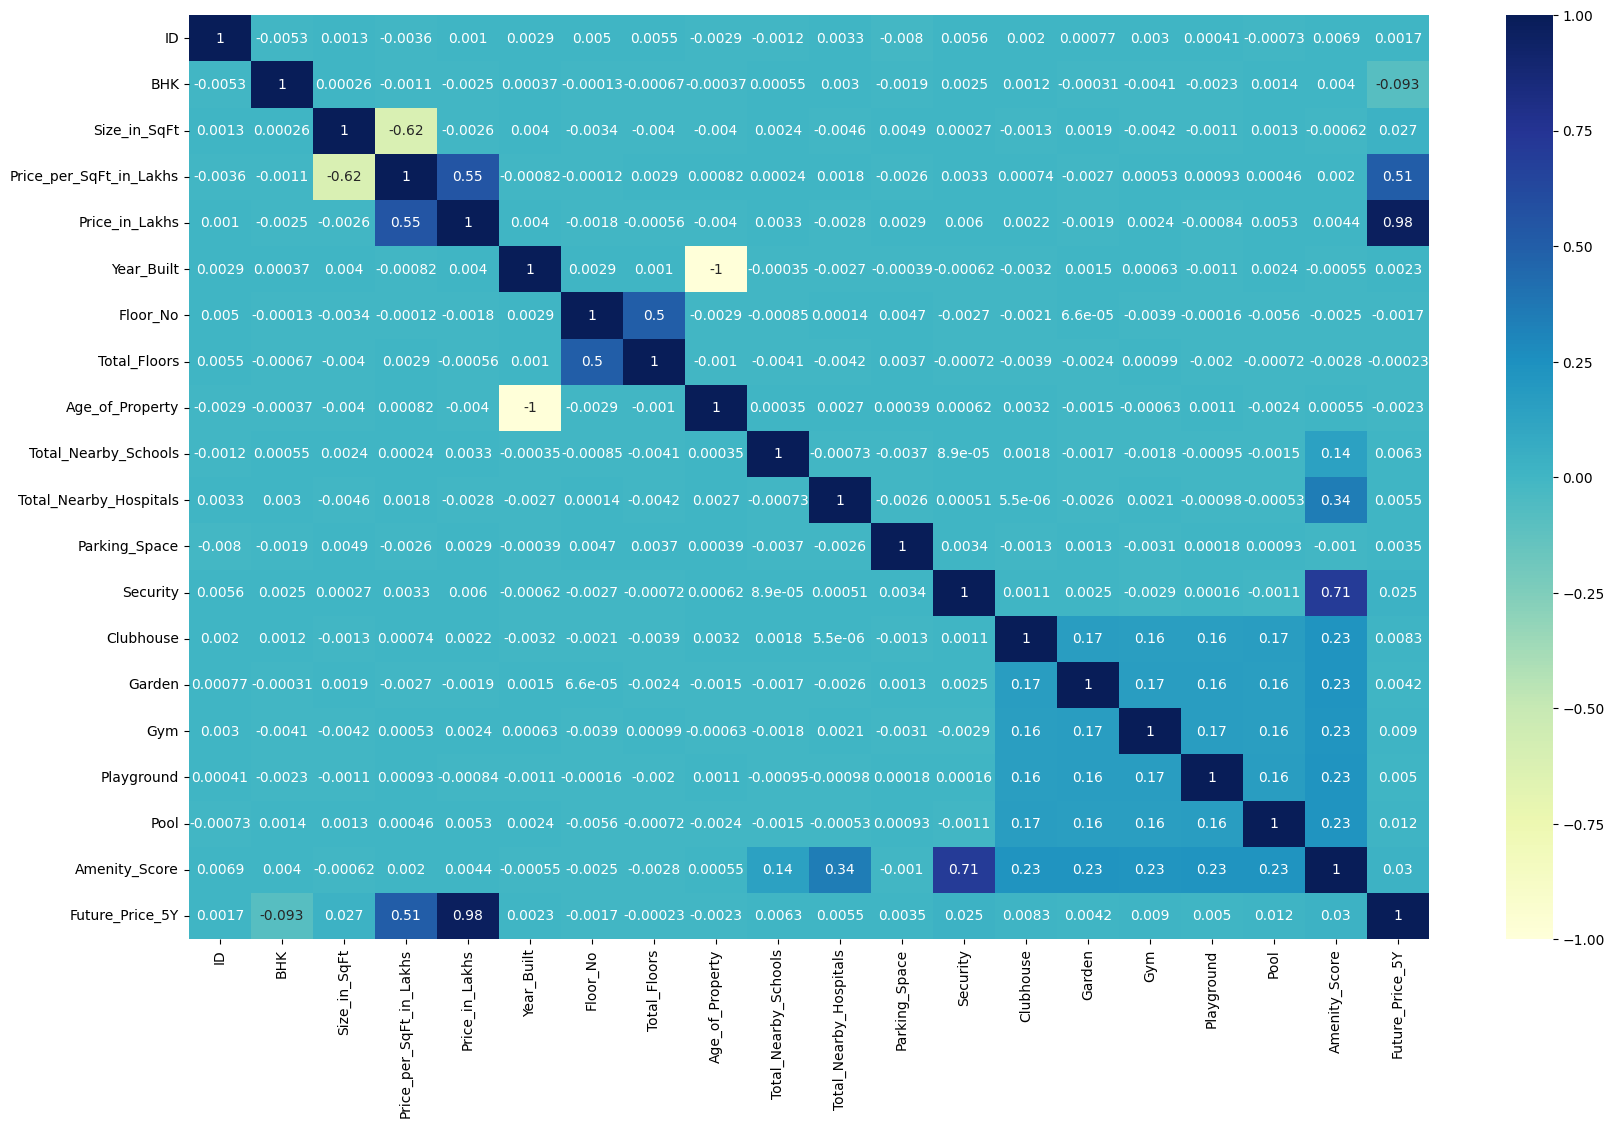

In [50]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(20,12))
sns.heatmap(
  data=corr,
  annot=True,
  cmap='YlGnBu'
)
plt.show()

### Feature Variable and Target variable

In [51]:
X = data.drop(columns=['ID', 'Future_Price_5Y', 'Price_in_Lakhs', 'Amenity_Score', 'Year_Built', 'State'])
y = data['Future_Price_5Y']

### Feature selection using Mutual Information

In [52]:
"""X_encoded = X.copy()

for col in X_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

mi_scores = mutual_info_regression(X_encoded, y)

mi_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'MI_Score': mi_scores
})

mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

print(mi_df)"""

"X_encoded = X.copy()\n\nfor col in X_encoded.select_dtypes(include=['object']).columns:\n    le = LabelEncoder()\n    X_encoded[col] = le.fit_transform(X_encoded[col])\n\nmi_scores = mutual_info_regression(X_encoded, y)\n\nmi_df = pd.DataFrame({\n    'Feature': X_encoded.columns,\n    'MI_Score': mi_scores\n})\n\nmi_df = mi_df.sort_values(by='MI_Score', ascending=False)\n\nprint(mi_df)"

In [53]:
"""mi_df.sort_values(by='MI_Score').plot(
    x='Feature',
    y='MI_Score',
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance (Information Gain)")
plt.show()"""

'mi_df.sort_values(by=\'MI_Score\').plot(\n    x=\'Feature\',\n    y=\'MI_Score\',\n    kind=\'barh\',\n    figsize=(8,6)\n)\n\nplt.title("Feature Importance (Information Gain)")\nplt.show()'

# Linear Regression

### Data Preprocessing Pipeline

In [54]:
# Target Encoding City and Locality
class LocationFeatureEngineer(BaseEstimator, TransformerMixin):
  def __init__(self, city_col='City', locality_col='Locality'):
    self.city_col = city_col
    self.locality_col = locality_col

  def extract_locality_number(self, val):
    val_list = val.split("_")
    return str(val_list[1])

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()

    # Extract locality number
    X[self.locality_col] = X[self.locality_col].apply(self.extract_locality_number)

    # Create Location feature
    X['Location'] = X[self.city_col] + '_' + X[self.locality_col]

    # Drop original columns
    X.drop(columns=[self.city_col, self.locality_col], inplace=True)

    return X


class SmoothedTargetEncoder(BaseEstimator, TransformerMixin):
  def __init__(self, col, smoothing=10):
    self.col = col
    self.smoothing = smoothing

  def fit(self, X, y):
    df = pd.DataFrame({
      self.col: X[self.col],
      'target': y
    })

    stats = df.groupby(self.col)['target'].agg(['mean', 'count'])

    self.global_mean_ = y.mean()

    # Smoothing formula
    self.mapping_ = (
      (stats['mean'] * stats['count'] + self.global_mean_ * self.smoothing) /
      (stats['count'] + self.smoothing)
    )

    return self

  def transform(self, X):
    X = X.copy()

    X[self.col] = X[self.col].map(self.mapping_)

    # Handle unseen values
    X[self.col] = X[self.col].fillna(self.global_mean_)

    return X

location_pipeline = Pipeline([
  ('location_feature_engineering', LocationFeatureEngineer()),
  ('target_enc', SmoothedTargetEncoder(col='Location', smoothing=10))
])

cat_pipeline = Pipeline([
  ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

std_sle_pipeline = Pipeline([
  ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
  ('ordinal', OrdinalEncoder())
])

binary_pipeline = 'passthrough'


### Final Model Pipeline

In [55]:
# selected_features = mi_df[mi_df['MI_Score'] > 0]['Feature'].tolist()
selected_features = X.columns

lr_tar_var = []
lr_num_var = []
lr_cat_var = []
lr_ord_var = []
lr_bin_var = []

for var in selected_features:
    
    unique_vals = data[var].dropna().unique()

    
    if set(unique_vals).issubset({0, 1}):
        lr_bin_var.append(var)

    
    elif (data[var].dtype == 'float') or (data[var].dtype == 'int'):
        lr_num_var.append(var)
    
    elif data[var].dtype == 'object':
        if var in ['City', 'Locality']:
            lr_tar_var.append(var)
        elif var == 'Public_Transport_Accessibility':
            lr_ord_var.append(var)
        else:
            lr_cat_var.append(var)

lr_preprocessor = ColumnTransformer([
    ('location', location_pipeline, lr_tar_var),
    ('cat', cat_pipeline, lr_cat_var),
    ('num', std_sle_pipeline, lr_num_var),
    ('ordinal', ordinal_pipeline, lr_ord_var),
    ('bin', binary_pipeline, lr_bin_var)
])

lr_pipeline = Pipeline([
    ('preprocessing', lr_preprocessor),
    ('model', LinearRegression())
])

lr_tags = {
  "Feature Selection": "mutual_info_regression",
  "MI": "> 0",
  "model": "Linear Regression",
  "NumericalScalar":"StandardScaler"
}

print(lr_tar_var)
print(lr_num_var)
print(lr_cat_var)
print(lr_ord_var)
print(lr_bin_var)

['City', 'Locality']
['BHK', 'Size_in_SqFt', 'Price_per_SqFt_in_Lakhs', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Total_Nearby_Schools', 'Total_Nearby_Hospitals']
['Property_Type', 'Furnished_Status', 'Direction_Facing', 'Owner_Type', 'Availability_Status']
['Public_Transport_Accessibility']
['Parking_Space', 'Security', 'Clubhouse', 'Garden', 'Gym', 'Playground', 'Pool']


# Ridge Regression

In [56]:
ridge_pipeline = Pipeline([
    ('preprocessing', lr_preprocessor), # Same preprocessing as Linear Regression
    ('model', Ridge(
        alpha=1.0         # Regularization strength (tune this)
    ))
])

param_grid = {
    'model__alpha': [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_tags = {
  "Feature Selection": "Auto",
  "model": "Ridge Regression",
  "Regularization": "L2",
  "NumericalScalar": "StandardScaler"
}

# Lasso Regression

In [57]:
lasso_pipeline = Pipeline([
  ('preprocessing', lr_preprocessor),  # reuse same preprocessing
  ('model', Lasso(
      max_iter=10000,   # important for convergence
      random_state=42
  ))
])

param_grid = {
    'model__alpha': [1e-4, 1e-3, 1e-2, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
  lasso_pipeline,
  param_grid,
  cv=5,
  scoring='r2',
  n_jobs=-1
)

lasso_tags = {
  "Feature Selection": "L1 Regularization (Auto)",
  "model": "Lasso Regression",
  "Regularization": "L1",
  "NumericalScalar": "StandardScaler"
}

# Tree-Based Regression Models

### Feature Selection

In [58]:
selected_features = X.columns

rf_tar_var = []
rf_num_var = []
rf_cat_var = []
rf_ord_var = []
rf_bin_var = []

for var in selected_features:

    # Drop NA for safety when checking unique values
    unique_vals = data[var].dropna().unique()

    # ✅ Step 1: Detect Binary (0/1)
    if set(unique_vals).issubset({0, 1}):
        rf_bin_var.append(var)

    # ✅ Step 2: Numerical / Ordinal
    elif (data[var].dtype == 'float') or (data[var].dtype == 'int'):
        rf_num_var.append(var)

    # ✅ Step 3: Categorical
    elif data[var].dtype == 'object':
        if var in ['City', 'Locality']:
            rf_tar_var.append(var)
        elif var == 'Public_Transport_Accessibility':
            rf_ord_var.append(var)
        else:
            rf_cat_var.append(var)

print(rf_tar_var)
print(rf_num_var)
print(rf_cat_var)
print(rf_ord_var)
print(rf_bin_var)

['City', 'Locality']
['BHK', 'Size_in_SqFt', 'Price_per_SqFt_in_Lakhs', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Total_Nearby_Schools', 'Total_Nearby_Hospitals']
['Property_Type', 'Furnished_Status', 'Direction_Facing', 'Owner_Type', 'Availability_Status']
['Public_Transport_Accessibility']
['Parking_Space', 'Security', 'Clubhouse', 'Garden', 'Gym', 'Playground', 'Pool']


### Data Preprocessing Pipeline

In [59]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None):
        self.cols = cols

    def fit(self, X, y):
        X = pd.DataFrame(X, columns=self.cols)
        self.global_mean = y.mean()
        self.target_means = {}

        for col in self.cols:
            self.target_means[col] = y.groupby(X[col]).mean()

        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.cols)

        for col in self.cols:
            X[col] = X[col].map(self.target_means[col])
            X[col] = X[col].fillna(self.global_mean)

        return X.values

class OrdinalMapper(BaseEstimator, TransformerMixin):
    def __init__(self, mapping):
        self.mapping = mapping

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.mapping.keys())

        for col, map_dict in self.mapping.items():
            X[col] = X[col].map(map_dict)

        return X.values


# ----------------------------------
# Ordinal Mapping
# ----------------------------------
ordinal_mapping = {
    'Public_Transport_Accessibility': {
        'Low': 0,
        'Medium': 1,
        'High': 2
    }
}

# ----------------------------------
# Column Transformer
# ----------------------------------
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', rf_num_var),
        ('bin', 'passthrough', rf_bin_var),

        ('low_cat',
         OneHotEncoder(handle_unknown='ignore'),
         rf_cat_var),

        ('high_cat',
         TargetEncoder(cols=rf_tar_var),
         rf_tar_var),

        ('ordinal',
         OrdinalMapper(mapping=ordinal_mapping),
         rf_ord_var)
    ]
)


## Decision Tree Regressor

In [60]:
dt_pipeline = Pipeline([
    ('preprocessing', tree_preprocessor), 
    ('model', DecisionTreeRegressor(
        max_depth=15,
        min_samples_leaf=2,
        random_state=42
    ))
])

dt_tags = {
  "model": "Decision Tree Regressor",
  "Tree Type": "Single Tree",
  "NumericalScalar": "Not Required",
  "Handles Non-linearity": "Yes"
}

## Random Forest Regressor

In [61]:
rf_pipeline = Pipeline([
    ('preprocessing', tree_preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        min_samples_leaf=2,
        n_jobs=-1
    ))
])

rf_tags = {
  "model": "Random Forest Regressor",
  "NumericalScalar":"StandardScaler"
}

# XGBoost Regressor

In [62]:
xgb_pipeline = Pipeline([
    ('preprocessing', tree_preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_tags = {
    "model": "XGBoost Regressor",
    "Tree Type": "Boosted Trees",
    "NumericalScalar": "Not Required",
    "Handles Non-linearity": "Yes",
    "Handles Missing Values": "Yes"
}

# Model Performance Visualization

In [63]:
def log_regression_plot(y_true, y_pred, model_name, dataset_type="test"):

    plt.figure()

    # Scatter plot
    plt.scatter(y_true, y_pred, alpha=0.5)

    # Ideal line (perfect prediction)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{model_name} - {dataset_type} (Actual vs Predicted)")

    # Save plot
    os.makedirs("Images/Regression Plot", exist_ok=True)
    file_name = f"Images/Regression Plot/{model_name}_{dataset_type}_fit.png"
    plt.savefig(file_name)
    plt.close()

    return file_name

def log_residual_plot(y_true, y_pred, model_name):

    residuals = y_true - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0)

    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"{model_name} - Residual Plot")

    os.makedirs("Images/Residual Plot", exist_ok=True)

    file_name = f"Images/Residual Plot/{model_name}_residuals.png"
    plt.savefig(file_name)
    plt.close()

    return file_name

# Training and Testing Data

In [64]:
dataset_params = {
  'random_state':42,
  'test_size':0.2
}

X_train, X_test, y_train, y_test = train_test_split(
  X, y, random_state = dataset_params['random_state'], test_size=dataset_params['test_size']
)

# Tracking Model Experiments using MLFlow

In [65]:
models = [
  (
    "Linear_Regression",
    lr_pipeline,
    (X_train, y_train),
    (X_test, y_test),
    lr_tags
  ),
  (
    "Ridge_Regression",
    ridge_grid,
    (X_train, y_train),
    (X_test, y_test),
    ridge_tags
  ),
  (
    "Lasso_Regression",
    lasso_grid,
    (X_train, y_train),
    (X_test, y_test),
    lasso_tags
  ),
  (
    "Decision_Tree_Regressor",
    dt_pipeline,
    (X_train, y_train),
    (X_test, y_test),
    dt_tags
  ),
  (
    "Random_Forest_Regressor",
    rf_pipeline,
    (X_train, y_train),
    (X_test, y_test),
    rf_tags
  ),
  (
    "XGBoost_Regressor",
    xgb_pipeline,
    (X_train, y_train),
    (X_test, y_test),
    xgb_tags
  )
]

In [66]:
model_reports = []
model_tags = []

# -------------------------
# TRAINING LOOP
# -------------------------
for model_name, model, train_set, test_set, tags in models:

  model_tags.append(tags)

  X_train = train_set[0]
  y_train = train_set[1]
  X_test = test_set[0]
  y_test = test_set[1]

  model.fit(X_train, y_train)
  print(f"{model_name} Trained")

  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  model_metrics = {
    "train_r2": r2_score(y_train, y_train_pred),
    "test_r2": r2_score(y_test, y_test_pred),

    "train_mae": mean_absolute_error(y_train, y_train_pred),
    "test_mae": mean_absolute_error(y_test, y_test_pred),

    "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
    "test_rmse": np.sqrt(mean_squared_error(y_test, y_test_pred)),
  }

  model_reports.append(model_metrics)


Linear_Regression Trained
Ridge_Regression Trained
Lasso_Regression Trained
Decision_Tree_Regressor Trained
Random_Forest_Regressor Trained
XGBoost_Regressor Trained


# Dagshub Connection

In [67]:
import dagshub

dagshub.init(
  repo_owner='JS-Tharun', 
  repo_name='Real-Estate-Investment-Advisor', 
  mlflow=True
)

Initialized MLflow to track repo "JS-Tharun/Real-Estate-Investment-Advisor"

Repository JS-Tharun/Real-Estate-Investment-Advisor initialized!

In [68]:
# -------------------------
# MLFLOW LOGGING LOOP
# -------------------------
load_dotenv()

os.environ['MLFLOW_TRACKING_USERNAME'] = f"{os.getenv('DAGSHUB_USERNAME')}"
os.environ['MLFLOW_TRACKING_PASSWORD'] = f"{os.getenv('DAGSHUB_PASSWORD')}"

mlflow.set_experiment(os.environ["MLFLOW_EXPERIMENT_NAME_REG"])
mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])

for i, element in enumerate(models):

  model_name = element[0]
  model = element[1]
  report = model_reports[i]

  X_train = element[2][0]
  y_train = element[2][1]
  X_test = element[3][0]
  y_test = element[3][1]

  dataset = from_pandas(X_train, name="X_train_dataset")
  model_tag = model_tags[i]

  with mlflow.start_run(run_name=model_name):

    mlflow.log_input(dataset, context='training_data')
    print("Input Logged")

    mlflow.set_tags(model_tag)
    print("Tag Logged")

    mlflow.log_param('model_name', model_name)

    # ✅ Handle GridSearchCV vs normal pipeline
    if hasattr(model, "best_estimator_"):
        model_to_log = model.best_estimator_

        mlflow.log_params(model.best_params_)
        mlflow.log_params(model_to_log.named_steps['model'].get_params())

        # ✅ Log best alpha explicitly
        if 'model__alpha' in model.best_params_:
            mlflow.log_param("best_alpha", model.best_params_['model__alpha'])

    else:
        model_to_log = model
        mlflow.log_params(model.named_steps['model'].get_params())

    print("Params Logged")

    mlflow.log_metrics(report)
    print("Metrics Logged")

    mlflow.sklearn.log_model(
      model_to_log, 
      model_name
    )
    print("Model Logged")

    # ✅🔥 CRITICAL FIX: Recompute predictions per model
    y_train_pred = model_to_log.predict(X_train)
    y_test_pred = model_to_log.predict(X_test)

    # Generate plots
    train_plot = log_regression_plot(y_train, y_train_pred, model_name, "train")
    test_plot = log_regression_plot(y_test, y_test_pred, model_name, "test")
    residual_plot = log_residual_plot(y_test, y_test_pred, model_name)

    # Log artifacts
    mlflow.log_artifact(train_plot, artifact_path="plots")
    mlflow.log_artifact(test_plot, artifact_path="plots")
    mlflow.log_artifact(residual_plot, artifact_path="plots")

    print("Plots Logged")

Input Logged
Tag Logged
Params Logged


2026/04/13 01:40:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Metrics Logged


2026/04/13 01:40:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model Logged
Plots Logged
🏃 View run Linear_Regression at: https://dagshub.com/JS-Tharun/Real-Estate-Investment-Advisor.mlflow/#/experiments/0/runs/b9589555127d48d48b450399526f5089
🧪 View experiment at: https://dagshub.com/JS-Tharun/Real-Estate-Investment-Advisor.mlflow/#/experiments/0
Input Logged
Tag Logged
Params Logged


...

Model Logged
Plots Logged
🏃 View run Random_Forest_Regressor at: https://dagshub.com/JS-Tharun/Real-Estate-Investment-Advisor.mlflow/#/experiments/0/runs/5c8911584b4c43c2ae00dfb30e6fe57c
🧪 View experiment at: https://dagshub.com/JS-Tharun/Real-Estate-Investment-Advisor.mlflow/#/experiments/0
Input Logged
Tag Logged
Params Logged


2026/04/13 01:43:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Metrics Logged


2026/04/13 01:43:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model Logged
Plots Logged
🏃 View run XGBoost_Regressor at: https://dagshub.com/JS-Tharun/Real-Estate-Investment-Advisor.mlflow/#/experiments/0/runs/64df1698efa8481dad4bc1c0fc3555b4
🧪 View experiment at: https://dagshub.com/JS-Tharun/Real-Estate-Investment-Advisor.mlflow/#/experiments/0


# Model Registration

In [69]:
"""import dagshub

dagshub.init(
  repo_owner='JS-Tharun',
  repo_name='Real-Estate-Investment-Advisor',
  mlflow=True
)

mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])

model_name = "XGBoost_Regressor"
run_id = input("Enter model Run_ID")
model_uri = f"runs:/{run_id}/{model_name}"

result = mlflow.register_model(
  model_uri=model_uri, 
  name=model_name
)"""

'import dagshub\n\ndagshub.init(\n  repo_owner=\'JS-Tharun\',\n  repo_name=\'Real-Estate-Investment-Advisor\',\n  mlflow=True\n)\n\nmlflow.set_tracking_uri(os.environ[\'MLFLOW_TRACKING_URI\'])\n\nmodel_name = "XGBoost_Regressor"\nrun_id = input("Enter model Run_ID")\nmodel_uri = f"runs:/{run_id}/{model_name}"\n\nresult = mlflow.register_model(\n  model_uri=model_uri, \n  name=model_name\n)'

# Load and Test the Model

In [70]:
"""model_name = "XGBoost_Price_Pred"
model_uri=f"models:/{model_name}@challenger"

loaded_model = mlflow.pyfunc.load_model(model_uri)
y_pred = loaded_model.predict(X_test)
y_pred"""

'model_name = "XGBoost_Price_Pred"\nmodel_uri=f"models:/{model_name}@challenger"\n\nloaded_model = mlflow.pyfunc.load_model(model_uri)\ny_pred = loaded_model.predict(X_test)\ny_pred'

# Transition the Model to Production

In [71]:
"""dev_model_uri = f"models:/{model_name}@challenger"
prod_model = "Future_Price_Predictor-Prod"

client = mlflow.MlflowClient()

new_version = client.copy_model_version(src_model_uri=dev_model_uri, dst_name=prod_model)
client.set_registered_model_alias(
    name=prod_model,
    alias="champion",
    version=new_version.version
)"""

'dev_model_uri = f"models:/{model_name}@challenger"\nprod_model = "Future_Price_Predictor-Prod"\n\nclient = mlflow.MlflowClient()\n\nnew_version = client.copy_model_version(src_model_uri=dev_model_uri, dst_name=prod_model)\nclient.set_registered_model_alias(\n    name=prod_model,\n    alias="champion",\n    version=new_version.version\n)'

# Testing Production Model

In [72]:
"""model_uri=f"models:/{prod_model}@champion"

loaded_model = mlflow.sklearn.load_model(model_uri)
y_pred = loaded_model.predict(X_test)
y_pred"""

'model_uri=f"models:/{prod_model}@champion"\n\nloaded_model = mlflow.sklearn.load_model(model_uri)\ny_pred = loaded_model.predict(X_test)\ny_pred'

# Model Feature Importance

In [73]:
"""prod_model = "Future_Price_Predictor-Prod"
model_uri=f"models:/{prod_model}@champion"
unwrapped = mlflow.sklearn.load_model(model_uri)"""

'prod_model = "Future_Price_Predictor-Prod"\nmodel_uri=f"models:/{prod_model}@champion"\nunwrapped = mlflow.sklearn.load_model(model_uri)'

In [75]:
"""# ── Load as sklearn pipeline ──
preprocessor = unwrapped.named_steps['preprocessing']
xgb_model = unwrapped.named_steps['model']

# ── Reconstruct feature names in ColumnTransformer output order ──

# 1. Passthrough columns (come out as-is)
num_features = rf_num_var
bin_features = rf_bin_var

# 2. OneHotEncoded columns
ohe = preprocessor.named_transformers_['low_cat']
ohe_features = ohe.get_feature_names_out(rf_cat_var).tolist()

# 3. TargetEncoded columns (same names, just encoded)
tar_features = rf_tar_var

# 4. Ordinal mapped columns (same names, just mapped)
ord_features = rf_ord_var

# ── Combine in the exact same order as ColumnTransformer ──
all_feature_names = (
    list(num_features) +
    list(bin_features) +
    ohe_features +
    list(tar_features) +
    list(ord_features)
)

print(f"Total features: {len(all_feature_names)}")

# ── Sanity check: should match XGBoost's expected input shape ──
print(f"XGBoost n_features_in_: {xgb_model.n_features_in_}")
assert len(all_feature_names) == xgb_model.n_features_in_, \
    f"Mismatch! Got {len(all_feature_names)}, expected {xgb_model.n_features_in_}"""

'# ── Load as sklearn pipeline ──\npreprocessor = unwrapped.named_steps[\'preprocessing\']\nxgb_model = unwrapped.named_steps[\'model\']\n\n# ── Reconstruct feature names in ColumnTransformer output order ──\n\n# 1. Passthrough columns (come out as-is)\nnum_features = rf_num_var\nbin_features = rf_bin_var\n\n# 2. OneHotEncoded columns\nohe = preprocessor.named_transformers_[\'low_cat\']\nohe_features = ohe.get_feature_names_out(rf_cat_var).tolist()\n\n# 3. TargetEncoded columns (same names, just encoded)\ntar_features = rf_tar_var\n\n# 4. Ordinal mapped columns (same names, just mapped)\nord_features = rf_ord_var\n\n# ── Combine in the exact same order as ColumnTransformer ──\nall_feature_names = (\n    list(num_features) +\n    list(bin_features) +\n    ohe_features +\n    list(tar_features) +\n    list(ord_features)\n)\n\nprint(f"Total features: {len(all_feature_names)}")\n\n# ── Sanity check: should match XGBoost\'s expected input shape ──\nprint(f"XGBoost n_features_in_: {xgb_model

In [76]:
"""# ── Map importance scores to feature names ──
importance_df = (
    pd.DataFrame({
        'feature': all_feature_names,
        'importance': xgb_model.feature_importances_   # 'weight' by default
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

# ── For 'gain' based importance (more meaningful) ──
booster = xgb_model.get_booster()
booster.feature_names = all_feature_names   # Assign names to booster

gain_scores = booster.get_score(importance_type='gain')
gain_df = (
    pd.DataFrame(gain_scores.items(), columns=['feature', 'gain_importance'])
    .sort_values('gain_importance', ascending=False)
    .reset_index(drop=True)
)

# Note: get_score() only returns features that were actually used in splits,
# so gain_df may have fewer rows than all_feature_names — that's expected

print(importance_df)"""

"# ── Map importance scores to feature names ──\nimportance_df = (\n    pd.DataFrame({\n        'feature': all_feature_names,\n        'importance': xgb_model.feature_importances_   # 'weight' by default\n    })\n    .sort_values('importance', ascending=False)\n    .reset_index(drop=True)\n)\n\n# ── For 'gain' based importance (more meaningful) ──\nbooster = xgb_model.get_booster()\nbooster.feature_names = all_feature_names   # Assign names to booster\n\ngain_scores = booster.get_score(importance_type='gain')\ngain_df = (\n    pd.DataFrame(gain_scores.items(), columns=['feature', 'gain_importance'])\n    .sort_values('gain_importance', ascending=False)\n    .reset_index(drop=True)\n)\n\n# Note: get_score() only returns features that were actually used in splits,\n# so gain_df may have fewer rows than all_feature_names — that's expected\n\nprint(importance_df)"

## Mutual Information Gain

In [77]:
"""X_encoded = X.copy()

for col in X_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

mi_scores = mutual_info_regression(X_encoded, y)

mi_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'MI_Score': mi_scores
})

mi_df = mi_df.sort_values(by='MI_Score', ascending=False)"""

"X_encoded = X.copy()\n\nfor col in X_encoded.select_dtypes(include=['object']).columns:\n    le = LabelEncoder()\n    X_encoded[col] = le.fit_transform(X_encoded[col])\n\nmi_scores = mutual_info_regression(X_encoded, y)\n\nmi_df = pd.DataFrame({\n    'Feature': X_encoded.columns,\n    'MI_Score': mi_scores\n})\n\nmi_df = mi_df.sort_values(by='MI_Score', ascending=False)"

In [78]:
"""feature_score = mi_df.set_index('Feature')['MI_Score'].rank(ascending=False, method='min').to_dict()"""

"feature_score = mi_df.set_index('Feature')['MI_Score'].rank(ascending=False, method='min').to_dict()"

In [79]:
"""# Visualization
mi_df.sort_values(by='MI_Score').plot(
    x='Feature',
    y='MI_Score',
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance (Information Gain)")
plt.show()"""

'# Visualization\nmi_df.sort_values(by=\'MI_Score\').plot(\n    x=\'Feature\',\n    y=\'MI_Score\',\n    kind=\'barh\',\n    figsize=(8,6)\n)\n\nplt.title("Feature Importance (Information Gain)")\nplt.show()'

# Confidence Score for the model prediction

In [80]:
dagshub.init(
  repo_owner='JS-Tharun', 
  repo_name='Real-Estate-Investment-Advisor', 
  mlflow=True
)

load_dotenv()

os.environ['MLFLOW_TRACKING_USERNAME'] = f"{os.getenv('DAGSHUB_USERNAME')}"
os.environ['MLFLOW_TRACKING_PASSWORD'] = f"{os.getenv('DAGSHUB_PASSWORD')}"

Initialized MLflow to track repo "JS-Tharun/Real-Estate-Investment-Advisor"

Repository JS-Tharun/Real-Estate-Investment-Advisor initialized!

In [81]:
prod_model = ["XGBoost_Price_Pred", "RF_Price_Pred_Prod", "DT_Price_Pred_Prod"]
predictions = []

for model in prod_model:
    model_uri = f"models:/{model}@champion"
    loaded_model = mlflow.pyfunc.load_model(model_uri)
    y_pred = loaded_model.predict(X_test[0:1])
    print(f"Predictions from {model}: {y_pred}")
    predictions.append(y_pred)

mean_pred = np.mean(predictions, axis=0)
std_dev = np.std(predictions, axis=0)

confidence = 1 / (1 + (std_dev / mean_pred))
lower = mean_pred - 2 * std_dev
upper = mean_pred + 2 * std_dev

def confidence_label(conf):
    if conf > 0.8:
        return "High"
    elif conf > 0.6:
        return "Medium"
    else:
        return "Low"

conf_value = float(confidence[0])
conf_pct = round(conf_value * 100, 2)
conf_tier = confidence_label(conf_value)

print("\n========== Ensemble Prediction Result ==========")
print(f"Predicted Price     : ${mean_pred[0]:,.2f}")
print(f"Expected Price Range: ${lower[0]:,.2f}  —  ${upper[0]:,.2f}")
print(f"Confidence          : {conf_pct}% ({conf_tier})")
print("================================================")

Predictions from XGBoost_Price_Pred: [692.9]


Predictions from RF_Price_Pred_Prod: [679.34978434]


Predictions from DT_Price_Pred_Prod: [637.22953291]

========== Ensemble Prediction Result ==========
Predicted Price     : $669.83
Expected Price Range: $622.42  —  $717.23
Confidence          : 96.58% (High)
